# RNN & Word Embeddings for SEC Filings to Predict Returns

RNNs are commonly applied to various natural language processing tasks. We've already encountered sentiment analysis using text data in part three of this book.

We are now going to apply an RNN model to SEC filings to learn custom word embeddings (see Chapter 16) and predict the returns over the week after the filing date.

## Imports & Settings

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
%matplotlib inline

from pathlib import Path
import time
from collections import Counter
from datetime import timedelta
from tqdm import tqdm

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import yfinance as yf

from gensim.models.word2vec import LineSentence
from gensim.models.phrases import Phrases, Phraser

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    GRU,
    Bidirectional,
    Embedding,
    BatchNormalization,
    Dropout,
)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
gpu_devices = tf.config.experimental.list_physical_devices("GPU")
if gpu_devices:
    print("Using GPU")
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print("Using CPU")

Using CPU


In [4]:
np.random.seed(42)
tf.random.set_seed(42)

In [5]:
idx = pd.IndexSlice
sns.set_style("whitegrid")

In [6]:
def format_time(t):
    m, s = divmod(t, 60)
    h, m = divmod(m, 60)
    return f"{h:02.0f}:{m:02.0f}:{s:02.0f}"

In [7]:
deciles = np.arange(0.1, 1, 0.1).round(1)

## Get stock price data

### Paths

In [8]:
data_path = Path("..", "data", "sec-filings")

In [9]:
results_path = Path("results", "sec-filings")

selected_section_path = results_path / "ngrams_1"
ngram_path = results_path / "ngrams"
vector_path = results_path / "vectors"

for path in [vector_path, selected_section_path, ngram_path]:
    if not path.exists():
        path.mkdir(parents=True)

### Get filing info

In [10]:
filing_index = pd.read_csv(
    data_path / "filing_index.csv", parse_dates=["DATE_FILED"]
).rename(columns=str.lower)
filing_index.index += 1

In [11]:
filing_index.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22631 entries, 1 to 22631
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   cik           22631 non-null  int64         
 1   company_name  22631 non-null  object        
 2   form_type     22631 non-null  object        
 3   date_filed    22631 non-null  datetime64[ns]
 4   edgar_link    22631 non-null  object        
 5   quarter       22631 non-null  int64         
 6   ticker        22631 non-null  object        
 7   sic           22461 non-null  object        
 8   exchange      20619 non-null  object        
 9   hits          22555 non-null  object        
 10  year          22631 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(7)
memory usage: 1.9+ MB


In [12]:
filing_index.head()

,cik,company_name,form_type,date_filed,edgar_link,quarter,ticker,sic,exchange,hits,year
1,1000180,SANDISK CORP,10-K,2013-02-19,edgar/data/1000180/0001000180-13-000009.txt,1,SNDK,3572,NASDAQ,3,2013
2,1000209,MEDALLION FINANCIAL CORP,10-K,2013-03-13,edgar/data/1000209/0001193125-13-103504.txt,1,TAXI,6199,NASDAQ,0,2013
3,1000228,HENRY SCHEIN INC,10-K,2013-02-13,edgar/data/1000228/0001000228-13-000010.txt,1,HSIC,5047,NASDAQ,3,2013
4,1000229,CORE LABORATORIES N V,10-K,2013-02-19,edgar/data/1000229/0001000229-13-000009.txt,1,CLB,1389,NYSE,2,2013
5,1000232,KENTUCKY BANCSHARES INC KY,10-K,2013-03-28,edgar/data/1000232/0001104659-13-025094.txt,1,KTYB,6022,OTC,0,2013


In [13]:
pd.unique(filing_index.ticker)

array(['SNDK', 'TAXI', 'HSIC', ..., 'ATKR', 'ADNT', 'VVV'], dtype=object)

In [14]:
filing_index.ticker.nunique()

6630

In [15]:
filing_index.date_filed.describe()

count                            22631
mean     2014-09-24 01:30:47.960761856
min                2013-01-02 00:00:00
25%                2013-10-31 00:00:00
50%                2014-09-24 00:00:00
75%                2015-09-17 00:00:00
max                2016-12-30 00:00:00
Name: date_filed, dtype: object

### Download stock price data using Yfinance

`yfinance` can be unstable so that connections drop; if you experience this you may want to store intermediate results so you don't have to start over.

In [ ]:
# yf_data, missing = [], []
# for i, (symbol, dates) in enumerate(filing_index.groupby("ticker").date_filed, 1):
#     if i % 250 == 0:
#         print(i, len(yf_data), len(set(missing)), flush=True)

#     ticker = yf.Ticker(symbol)
#     for filing, date in dates.to_dict().items():
#         start = date - timedelta(days=93)
#         end = date + timedelta(days=31)
#         df = ticker.history(start=start, end=end)
#         if df.empty:
#             missing.append(symbol)
#         else:
#             yf_data.append(df.assign(ticker=symbol, filing=filing))

In [ ]:
yf_data = pd.concat(yf_data).rename(columns=str.lower)

In [ ]:
yf_data.to_hdf(results_path / "sec_returns.h5", "data/yfinance")

In [ ]:
yf_data = pd.read_hdf(results_path / "sec_returns.h5", "data/yfinance")

In [ ]:
yf_data.ticker.nunique()

In [ ]:
yf_data.info()

### Get (some) missing prices from Quandl

In [ ]:
to_do = filing_index.loc[
    ~filing_index.ticker.isin(yf_data.ticker.unique()), ["ticker", "date_filed"]
]

In [ ]:
to_do.date_filed.min()

In [16]:
quandl_tickers = (
    pd.read_hdf("../data/assets.h5", "quandl/wiki/prices")
    .loc[idx["2012":, :], :]
    .index.unique("ticker")
)
# quandl_tickers = list(set(quandl_tickers).intersection(set(to_do.ticker)))

In [17]:
len(quandl_tickers)

3199

In [18]:
to_do = filing_index.loc[
    filing_index.ticker.isin(quandl_tickers), ["ticker", "date_filed"]
]

In [19]:
to_do.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11378 entries, 1 to 22630
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ticker      11378 non-null  object        
 1   date_filed  11378 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(1)
memory usage: 266.7+ KB


In [20]:
ohlcv = ["adj_open", "adj_high", "adj_low", "adj_close", "adj_volume"]

In [21]:
quandl = (
    pd.read_hdf("../data/assets.h5", "quandl/wiki/prices")
    .loc[idx["2012":, quandl_tickers], ohlcv]
    .rename(columns=lambda x: x.replace("adj_", ""))
)

In [22]:
quandl.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 4480045 entries, (Timestamp('2012-01-02 00:00:00'), 'LFVN') to (Timestamp('2018-03-27 00:00:00'), 'ZUMZ')
Data columns (total 5 columns):
 #   Column  Dtype  
---  ------  -----  
 0   open    float64
 1   high    float64
 2   low     float64
 3   close   float64
 4   volume  float64
dtypes: float64(5)
memory usage: 188.8+ MB


In [24]:
to_do.head()

,ticker,date_filed
1,SNDK,2013-02-19
2,TAXI,2013-03-13
3,HSIC,2013-02-13
7,SWM,2013-03-01
8,NVAX,2013-03-12


In [26]:
quandl.loc[idx[:, 'AA'], :]

,,open,high,low,close,volume
date,ticker,,,,,
2016-11-01,AA,22.10,23.5500,21.7800,23.00,32216510.0
2016-11-02,AA,22.67,23.2650,22.6358,22.91,10755328.0
2016-11-03,AA,22.96,24.3493,22.9400,24.15,8083097.0
2016-11-04,AA,23.82,25.5000,23.5600,25.20,6878500.0
2016-11-07,AA,25.54,26.4100,24.8900,25.08,8377025.0
...,...,...,...,...,...,...
2018-03-21,AA,46.42,48.0615,46.3100,47.95,2104409.0
2018-03-22,AA,47.40,48.0890,44.8600,44.92,4312329.0
2018-03-23,AA,45.17,46.0000,44.6000,44.71,3221848.0


In [27]:
quandl_data = []
for i, (symbol, dates) in enumerate(to_do.groupby("ticker").date_filed, 1):
    if i % 100 == 0:
        print(i, end=" ", flush=True)
    for filing, date in dates.to_dict().items():
        start = date - timedelta(days=93)
        end = date + timedelta(days=31)
        try:
            quandl_data.append(
                quandl.loc[idx[start:end, symbol], :]
                .reset_index("ticker")
                .assign(filing=filing)
            )
        except KeyError:
            print(f"No data for {symbol} between {start} and {end}")
quandl_data = pd.concat(quandl_data)

No data for AA between 2012-11-14 00:00:00 and 2013-03-18 00:00:00
No data for AA between 2013-11-12 00:00:00 and 2014-03-16 00:00:00
No data for AA between 2014-11-18 00:00:00 and 2015-03-22 00:00:00
No data for AA between 2015-11-18 00:00:00 and 2016-03-21 00:00:00
No data for ABFS between 2014-11-29 00:00:00 and 2015-04-02 00:00:00
No data for ABFS between 2015-11-25 00:00:00 and 2016-03-28 00:00:00
No data for ACFN between 2015-12-28 00:00:00 and 2016-04-30 00:00:00
No data for ADES between 2012-12-15 00:00:00 and 2013-04-18 00:00:00
No data for ADES between 2015-11-28 00:00:00 and 2016-03-31 00:00:00
No data for ADES between 2016-01-17 00:00:00 and 2016-05-20 00:00:00
100 200 No data for ARSD between 2014-12-10 00:00:00 and 2015-04-13 00:00:00
No data for ARSD between 2015-12-09 00:00:00 and 2016-04-11 00:00:00
No data for ASBC between 2015-11-04 00:00:00 and 2016-03-07 00:00:00
No data for ATK between 2015-02-28 00:00:00 and 2015-07-02 00:00:00
No data for AVID between 2014-06-11

In [28]:
quandl_data

,ticker,open,high,low,close,volume,filing
date,,,,,,,
2013-09-17,A,33.764973,34.173784,33.688755,33.861979,1578400.0,5613
2013-09-18,A,33.792689,34.194571,33.460098,34.173784,2044200.0,5613
2013-09-19,A,36.668221,37.049315,35.163937,35.323996,18146400.0,5613
2013-09-20,A,35.362106,36.300984,35.323996,36.134688,10691900.0,5613
2013-09-23,A,35.968393,36.197049,35.601156,35.802097,2716900.0,5613
...,...,...,...,...,...,...,...
2016-04-08,ZUMZ,17.480000,17.550000,16.740000,17.310000,502256.0,18628
2016-04-11,ZUMZ,17.000000,17.300000,16.620000,16.990000,466246.0,18628
2016-04-12,ZUMZ,16.990000,17.250000,16.330000,17.050000,485357.0,18628


In [29]:
quandl_data.to_hdf(results_path / "sec_returns.h5", "data/quandl")

### Combine, clean and persist

In [ ]:
data = (
    pd.read_hdf(results_path / "sec_returns.h5", "data/yfinance")
    .drop(["dividends", "stock splits"], axis=1)
    .append(pd.read_hdf(results_path / "sec_returns.h5", "data/quandl"))
)

In [30]:
data = quandl_data

In [31]:
data = data.loc[:, ["filing", "ticker", "open", "high", "low", "close", "volume"]]

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 950103 entries, 2013-09-17 to 2016-04-14
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   filing  950103 non-null  int64  
 1   ticker  950103 non-null  object 
 2   open    950084 non-null  float64
 3   high    950102 non-null  float64
 4   low     950102 non-null  float64
 5   close   950103 non-null  float64
 6   volume  950103 non-null  float64
dtypes: float64(5), int64(1), object(1)
memory usage: 58.0+ MB


In [33]:
data[["filing", "ticker"]].nunique()

filing    11246
ticker     2985
dtype: int64

In [34]:
data.to_hdf(results_path / "sec_returns.h5", "prices")

## Copy filings with stock price data

In [35]:
data = pd.read_hdf(results_path / "sec_returns.h5", "prices")

In [36]:
filings_with_data = data.filing.unique()
len(filings_with_data)

11246

### Remove short and long sentences

In [37]:
min_sentence_length = 5
max_sentence_length = 50

In [38]:
sent_length = Counter()
for i, idx in enumerate(filings_with_data, 1):
    if i % 500 == 0:
        print(i, end=" ", flush=True)
    text = pd.read_csv(data_path / "selected_sections" / f"{idx}.csv").text
    sent_length.update(text.str.split().str.len().tolist())
    text = text[
        text.str.split().str.len().between(min_sentence_length, max_sentence_length)
    ]
    text = "\n".join(text.tolist())
    with (selected_section_path / f"{idx}.txt").open("w") as f:
        f.write(text)

500 1000 1500 2000 2500 3000 3500 4000 4500 5000 5500 6000 6500 7000 7500 8000 8500 9000 9500 10000 10500 11000 

In [39]:
sent_length = pd.Series(dict(sent_length.most_common()))

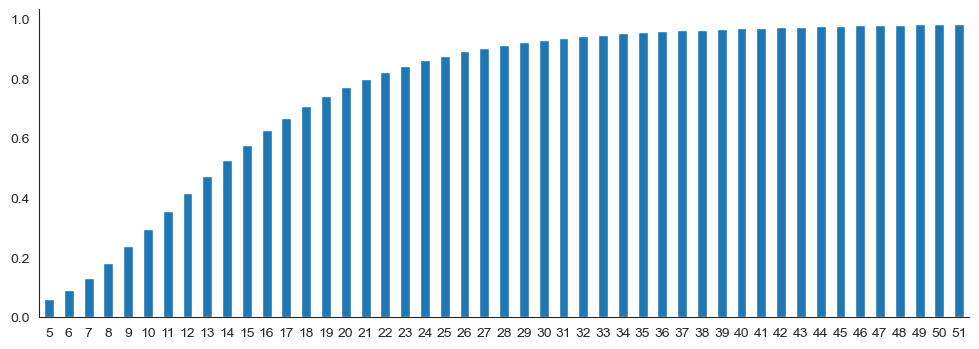

In [40]:
with sns.axes_style("white"):
    sent_length.sort_index().cumsum().div(sent_length.sum()).loc[5:51].plot.bar(
        figsize=(12, 4), rot=0
    )
    sns.despine()

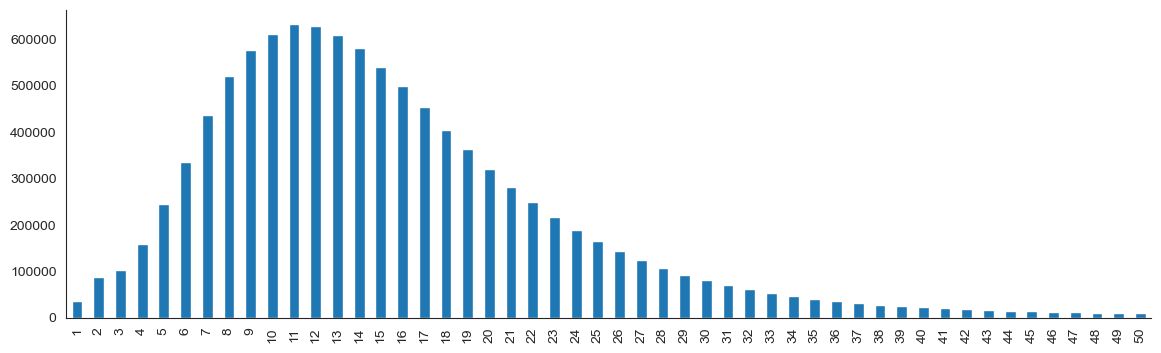

In [41]:
with sns.axes_style("white"):
    sent_length.sort_index().loc[:50].plot.bar(figsize=(14, 4))
    sns.despine()

### Create bi- and trigrams

Combine all filings

In [42]:
files = selected_section_path.glob("*.txt")
texts = [f.read_text() for f in files]
unigrams = ngram_path / "ngrams_1.txt"
unigrams.write_text("\n".join(texts))

1324481626

In [43]:
texts = unigrams.read_text()

This takes quite some time; last attempt was 30 min per iteration.

In [53]:
n_grams = []
start = time.time()
for i, n in enumerate([2, 3]):
    sentences = LineSentence(ngram_path / f"ngrams_{n - 1}.txt")
    phrases = Phrases(
        sentences=sentences,
        min_count=25,  # ignore terms with a lower count
        threshold=0.5,  # accept phrases with higher score
        max_vocab_size=4000000,  # prune of less common words to limit memory use
        delimiter="_",  # how to join ngram tokens
        scoring="npmi",
    )

    s = pd.DataFrame(
        [[k, v] for k, v in phrases.export_phrases().items()],
        columns=["phrase", "score"],
    ).assign(length=n)

    n_grams.append(s.groupby("phrase").score.agg(["mean", "size"]))
    print(n_grams[-1].nlargest(5, columns="size"))

    grams = Phraser(phrases)
    sentences = grams[sentences]
    (ngram_path / f"ngrams_{n}.txt").write_text(
        "\n".join([" ".join(s) for s in sentences])
    )

    src_dir = results_path / f"ngrams_{n - 1}"
    target_dir = results_path / f"ngrams_{n}"
    if not target_dir.exists():
        target_dir.mkdir()

    for f in src_dir.glob("*.txt"):
        text = LineSentence(f)
        text = grams[text]
        (target_dir / f"{f.stem}.txt").write_text(
            "\n".join([" ".join(s) for s in text])
        )
    print("\n\tDuration: ", format_time(time.time() - start))

n_grams = pd.concat(n_grams).sort_values("size", ascending=False)
n_grams.to_parquet(results_path / "ngrams.parquet")

              mean  size
phrase                  
aa_aa     0.570910     1
aa_baa    0.670743     1
aa_bbb    0.715267     1
aa_rated  0.552484     1
aaa_aa    0.744724     1

	Duration:  00:08:45
               mean  size
phrase                   
aa_aa      0.657698     1
aa_bbb     0.520399     1
aa_graded  0.532139     1
aa_median  0.516129     1
aa_rated   0.601956     1

	Duration:  00:18:56


In [54]:
n_grams.groupby(n_grams.index.str.replace("_", " ").str.count(" ")).size()

phrase
1    42352
2     5397
3     1105
dtype: int64

### Convert filings to integer sequences based on token count

In [55]:
sentences = (ngram_path / "ngrams_3.txt").read_text().split("\n")

In [56]:
n = len(sentences)

In [57]:
token_cnt = Counter()
for i, sentence in enumerate(sentences, 1):
    if i % 500000 == 0:
        print(f"{i / n:.1%}", end=" ", flush=True)
    token_cnt.update(sentence.split())
token_cnt = pd.Series(dict(token_cnt.most_common()))
token_cnt = token_cnt.reset_index()
token_cnt.columns = ["token", "n"]

5.0% 10.0% 15.1% 20.1% 25.1% 30.1% 35.2% 40.2% 45.2% 50.2% 55.2% 60.3% 65.3% 70.3% 75.3% 80.3% 85.4% 90.4% 95.4% 

In [58]:
token_cnt.to_parquet(results_path / "token_cnt")

In [59]:
token_cnt.n.describe(deciles).apply(lambda x: f"{x:,.0f}")

count      160,895
mean           853
std         11,111
min              1
10%              1
20%              2
30%              4
40%              7
50%             13
60%             26
70%             43
80%             88
90%            302
max      1,479,498
Name: n, dtype: object

In [60]:
token_cnt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160895 entries, 0 to 160894
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   token   160895 non-null  object
 1   n       160895 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.5+ MB


In [61]:
token_cnt.nlargest(10, columns="n")

,token,n
0,million,1479498
1,business,819522
2,products,765604
3,company,720602
4,net,650311
5,sales,633721
6,including,596050
7,costs,576118
8,market,568705
9,december,565844


In [62]:
token_cnt.sort_values(by=["n", "token"], ascending=[False, True]).head()

,token,n
0,million,1479498
1,business,819522
2,products,765604
3,company,720602
4,net,650311


In [63]:
token_by_freq = token_cnt.sort_values(by=["n", "token"], ascending=[False, True]).token
token2id = {token: i for i, token in enumerate(token_by_freq, 3)}

In [64]:
len(token2id)

160895

In [65]:
for token, i in token2id.items():
    print(token, i)
    break

million 3


In [66]:
def generate_sequences(min_len=100, max_len=20000, num_words=25000, oov_char=2):
    if not vector_path.exists():
        vector_path.mkdir()
    seq_length = {}
    skipped = 0
    for i, f in tqdm(enumerate((results_path / "ngrams_3").glob("*.txt"), 1)):
        file_id = f.stem
        text = f.read_text().split("\n")
        vector = [
            token2id[token] if token2id[token] + 2 < num_words else oov_char
            for line in text
            for token in line.split()
        ]
        vector = vector[:max_len]
        if len(vector) < min_len:
            skipped += 1
            continue
        seq_length[int(file_id)] = len(vector)
        np.save(vector_path / f"{file_id}.npy", np.array(vector))
    seq_length = pd.Series(seq_length)
    return seq_length

In [67]:
seq_length = generate_sequences()

11246it [02:50, 65.87it/s]


In [68]:
pd.Series(seq_length).to_csv(results_path / "seq_length.csv")

In [69]:
seq_length.describe(deciles)

count    11109.000000
mean     11911.758394
std       4657.829105
min        404.000000
10%       6128.000000
20%       7829.800000
30%       9056.400000
40%      10282.000000
50%      11521.000000
60%      12855.800000
70%      14321.000000
80%      16373.400000
90%      19488.200000
max      20000.000000
dtype: float64

In [70]:
seq_length.sum()

132327724

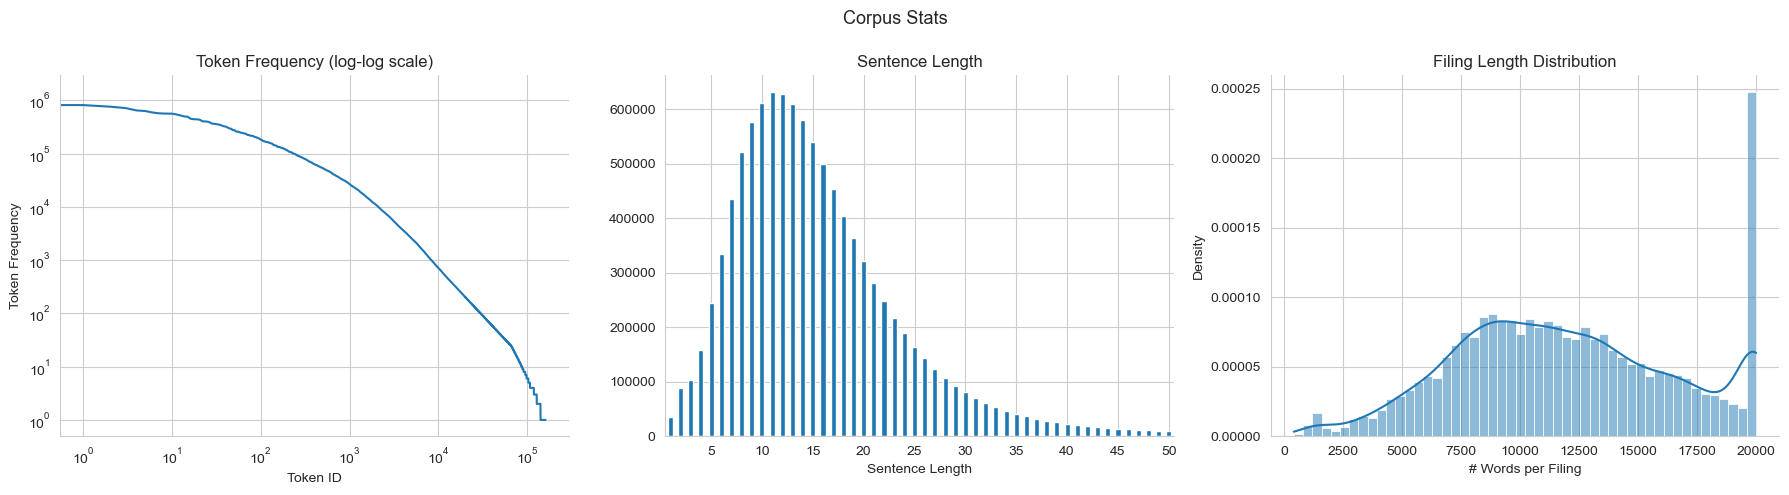

In [72]:
fig, axes = plt.subplots(ncols=3, figsize=(18, 5))
token_cnt.n.plot(
    logy=True, logx=True, ax=axes[0], title="Token Frequency (log-log scale)"
)
sent_length.sort_index().loc[:50].plot.bar(ax=axes[1], rot=0, title="Sentence Length")

n = 5
ticks = axes[1].xaxis.get_ticklocs()
ticklabels = [l.get_text() for l in axes[1].xaxis.get_ticklabels()]
axes[1].xaxis.set_ticks(ticks[n - 1 :: n])
axes[1].xaxis.set_ticklabels(ticklabels[n - 1 :: n])
axes[1].set_xlabel("Sentence Length")

sns.histplot(seq_length, ax=axes[2], bins=50, stat='density', kde=True)
axes[0].set_ylabel("Token Frequency")
axes[0].set_xlabel("Token ID")

axes[2].set_xlabel("# Words per Filing")
axes[2].set_title("Filing Length Distribution")

fig.suptitle("Corpus Stats", fontsize=13)
sns.despine()
fig.tight_layout()
fig.subplots_adjust(top=0.85)
fig.savefig(results_path / "sec_seq_len", dpi=300);

In [73]:
files = vector_path.glob("*.npy")
filings = sorted([int(f.stem) for f in files])

## Prepare Model Data

### Create weekly forward returns

In [74]:
prices = pd.read_hdf(results_path / "sec_returns.h5", "prices")
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 950103 entries, 2013-09-17 to 2016-04-14
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   filing  950103 non-null  int64  
 1   ticker  950103 non-null  object 
 2   open    950084 non-null  float64
 3   high    950102 non-null  float64
 4   low     950102 non-null  float64
 5   close   950103 non-null  float64
 6   volume  950103 non-null  float64
dtypes: float64(5), int64(1), object(1)
memory usage: 58.0+ MB


In [75]:
fwd_return = {}
for filing in filings:
    date_filed = filing_index.at[filing, "date_filed"]
    price_data = prices[prices.filing == filing].close.sort_index()

    try:
        r = price_data.pct_change(periods=5).shift(-5).loc[:date_filed].iloc[-1]
    except:
        continue
    if not np.isnan(r) and -0.5 < r < 1:
        fwd_return[filing] = r

In [76]:
len(fwd_return)

11058

### Combine returns with filing data

In [77]:
y, X = [], []
for filing_id, fwd_ret in fwd_return.items():
    X.append(np.load(vector_path / f"{filing_id}.npy") + 2)
    y.append(fwd_ret)
y = np.array(y)

In [78]:
len(y), len(X)

(11058, 11058)

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

### Pad sequences

In the second step, we convert the lists of integers into fixed-size arrays that we can stack and provide as input to our RNN. The pad_sequence function produces arrays of equal length, truncated, and padded to conform to maxlen, as follows:

In [80]:
maxlen = 20000

In [81]:
X_train = pad_sequences(X_train, truncating="pre", padding="pre", maxlen=maxlen)

X_test = pad_sequences(X_test, truncating="pre", padding="pre", maxlen=maxlen)

In [82]:
X_train.shape, X_test.shape

((9952, 20000), (1106, 20000))

## Define Model Architecture

Now we can define our RNN architecture. The first layer learns the word embeddings. We define the embedding dimension as previously using the input_dim keyword to set the number of tokens that we need to embed, the output_dim keyword, which defines the size of each embedding, and how long each input sequence is going to be.

In [84]:
embedding_size = 60

Note that we are using GRUs this time, which train faster and perform better on smaller data. We are also using dropout for regularization, as follows:

In [85]:
input_dim = X_train.max() + 1

In [88]:
rnn = Sequential(
    [
        Input(shape=(maxlen,)),
        Embedding(
            input_dim=input_dim,
            output_dim=embedding_size,
            name="EMB",
        ),
        BatchNormalization(name="BN1"),
        Bidirectional(GRU(32, dropout=0.1, recurrent_dropout=0.1), name="BD1"),
        BatchNormalization(name="BN2"),
        Dropout(0.2, name="DO1"),
        Dense(5, name="D"),
        Dense(1, activation="linear", name="OUT"),
    ]
)

The resulting model has over 2 million parameters.

In [89]:
rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ EMB (Embedding)                 │ (None, 20000, 60)      │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN1 (BatchNormalization)        │ (None, 20000, 60)      │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BD1 (Bidirectional)             │ (None, 64)             │        18,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN2 (BatchNormalization)        │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ DO1 (Dropout)                   │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ D (Dense)                       │ (None, 5)              │           325 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ OUT (Dense)                     │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,518,875 (5.79 MB)

 Trainable params: 1,518,627 (5.79 MB)

 Non-trainable params: 248 (992.00 B)

In [90]:
rnn.compile(
    loss="mse",
    optimizer="Adam",
    metrics=[RootMeanSquaredError(name="RMSE"), MeanAbsoluteError(name="MAE")],
)

## Train model

In [91]:
early_stopping = EarlyStopping(monitor="val_MAE", patience=5, restore_best_weights=True)

Training stops after eight epochs and we recover the weights for the best models to find a high test AUC of 0.9346:

In [ ]:
training = rnn.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1,
)

## Evaluate the Results

In [67]:
df = pd.DataFrame(training.history)
df.to_csv(results_path / "rnn_sec.csv", index=False)

In [68]:
df.index += 1

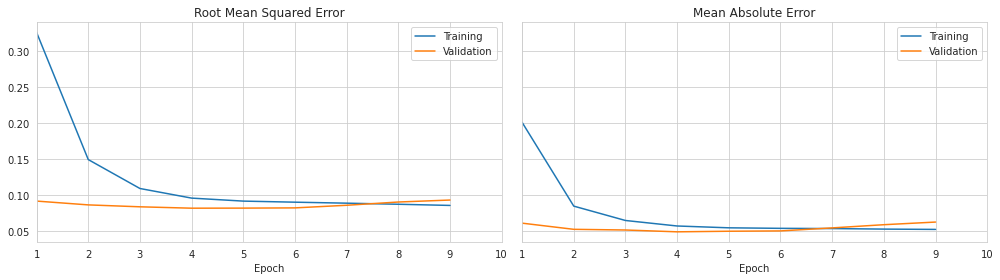

In [69]:
fig, axes = plt.subplots(ncols=2, figsize=(14, 4), sharey=True)
plot_data = df[["RMSE", "val_RMSE"]].rename(
    columns={"RMSE": "Training", "val_RMSE": "Validation"}
)
plot_data.plot(ax=axes[0], title="Root Mean Squared Error")

plot_data = df[["MAE", "val_MAE"]].rename(
    columns={"MAE": "Training", "val_MAE": "Validation"}
)
plot_data.plot(ax=axes[1], title="Mean Absolute Error")

for i in [0, 1]:
    axes[i].set_xlim(1, 10)
    axes[i].set_xlabel("Epoch")
fig.tight_layout()
fig.savefig(results_path / "sec_cv_performance", dpi=300);

In [70]:
y_score = rnn.predict(X_test)

In [71]:
rho, p = spearmanr(y_score.squeeze(), y_test)

In [75]:
print(f"Information Coefficient: {rho * 100:.2f} ({p:.2%})")

Information Coefficient: 7.65 (0.20%)


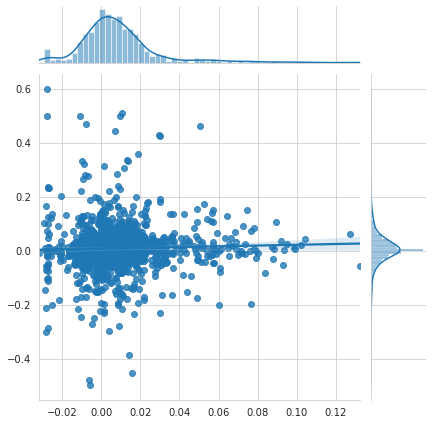

In [74]:
g = sns.jointplot(y_score.squeeze(), y_test, kind="reg");